# Customer Intelligence System - End-to-End Implementation

Developed an end-to-end Customer Intelligence System using classification, ensemble learning (Random Forest, XGBoost), and clustering (K-Means, Hierarchical, DBSCAN), achieving optimized predictive performance and actionable customer segmentation insights.

## 1) Import libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.cm as cm

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## 2) Load the dataset

Dataset link - kaggle kernels pull jatin2bagga/unsupervised-learning-on-country-data

In [6]:
# Option 1: Using Kaggle CLI (uncomment to use)
# !kaggle kernels pull jatin2bagga/unsupervised-learning-on-country-data

# Option 2: Using Kagglehub
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")

print("Path to dataset files:", path)

# Load the dataset
csv_path = os.path.join(path, "Country-data.csv")
df = pd.read_csv(csv_path)
display(df.head())

d:\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\rohan0301\unsupervised-learning-on-country-data\versions\2


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3) Quick inspection

In [7]:
print('Shape:', df.shape)
display(df.info())
display(df.describe(include='all').T)

Shape: (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


## 4) Basic cleaning

Handle missing values, remove duplicates, and make sure numeric columns are clean.

In [8]:
df = df.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = [c for c in df.columns if c != 'country']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

## 5) Exploratory Data Analysis (EDA)

Visualizing distributions, correlations, and checking for outliers.

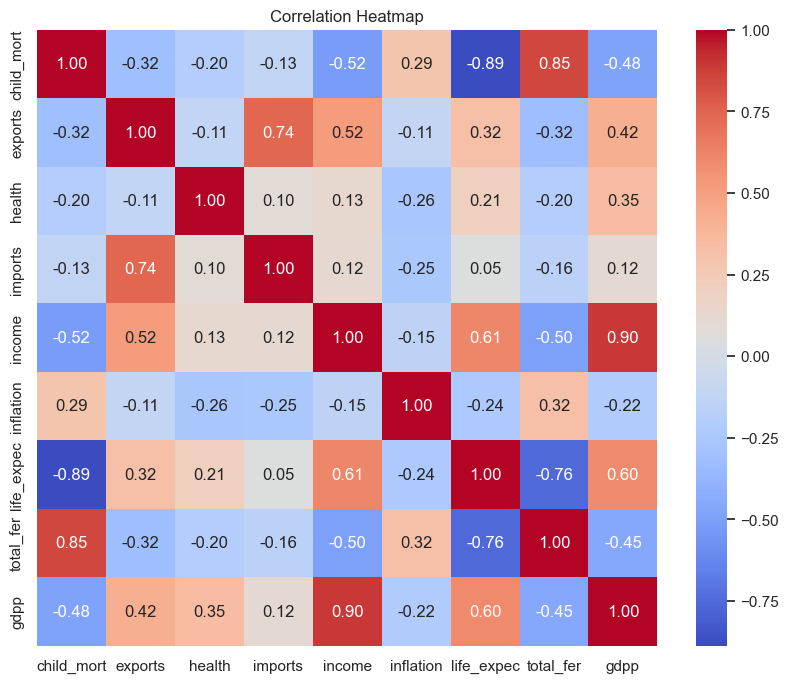

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

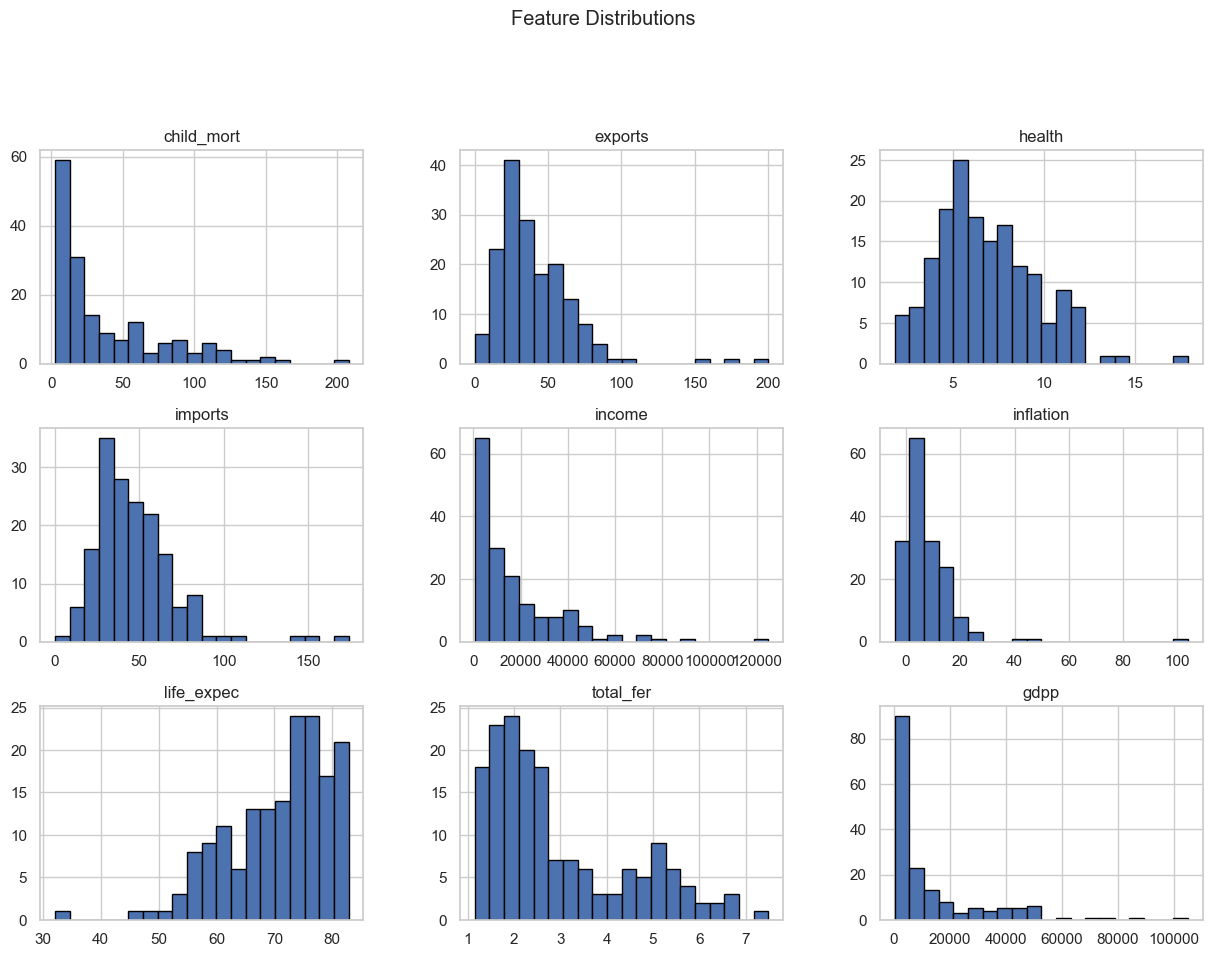

In [10]:
# Histograms for distributions
df[numeric_cols].hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.suptitle('Feature Distributions', y=1.02)
plt.show()

### Outlier Detection (Boxplots)

Identifying extreme values in our features.

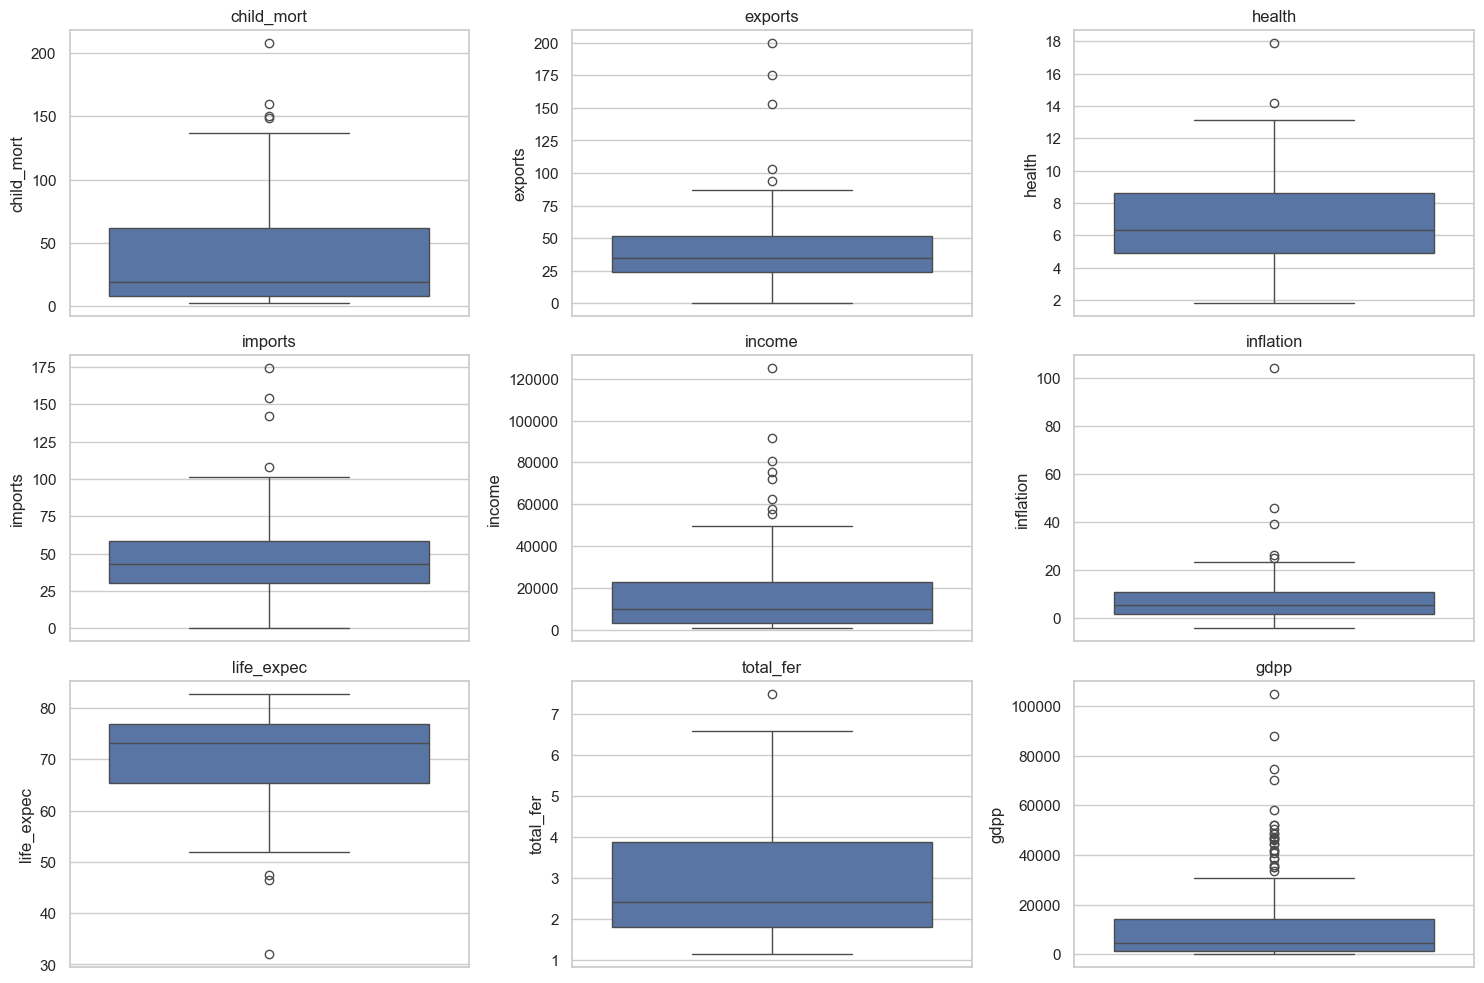

In [11]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### Pairplot

Visualizing pairwise relationships.

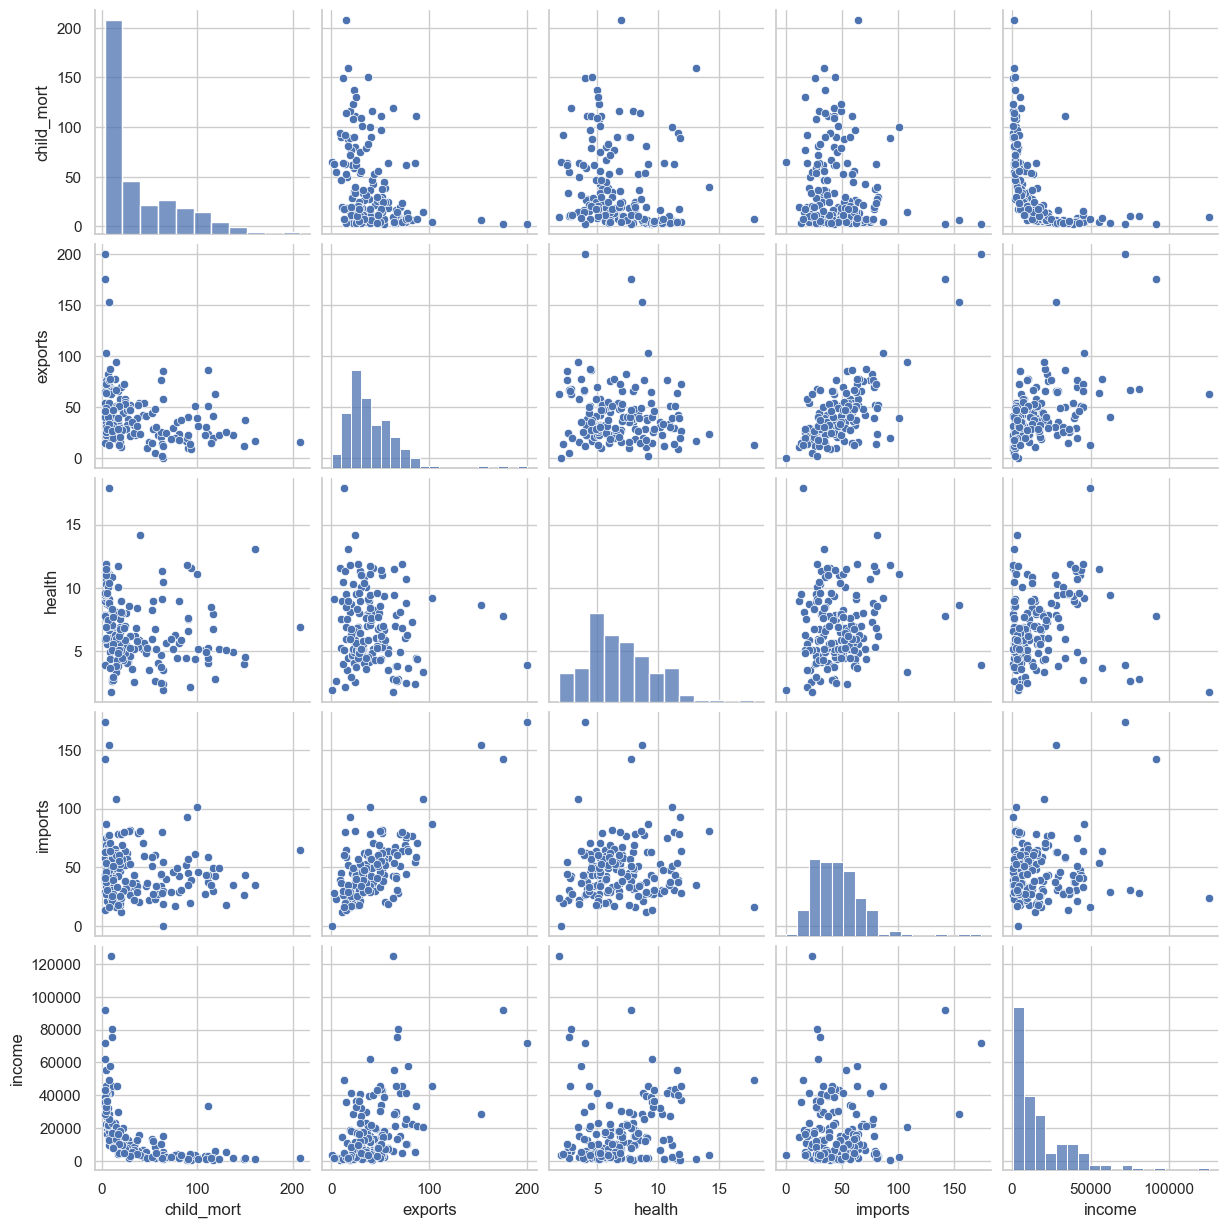

In [12]:
sns.pairplot(df[numeric_cols[:5]]) # Plotting first 5 for better readability
plt.show()

## 6) Feature Scaling

Standardization is crucial for distance-based clustering algorithms like K-Means and DBSCAN.

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)

## 7) K-Means Clustering

### Elbow Method

Finding the optimal number of clusters.

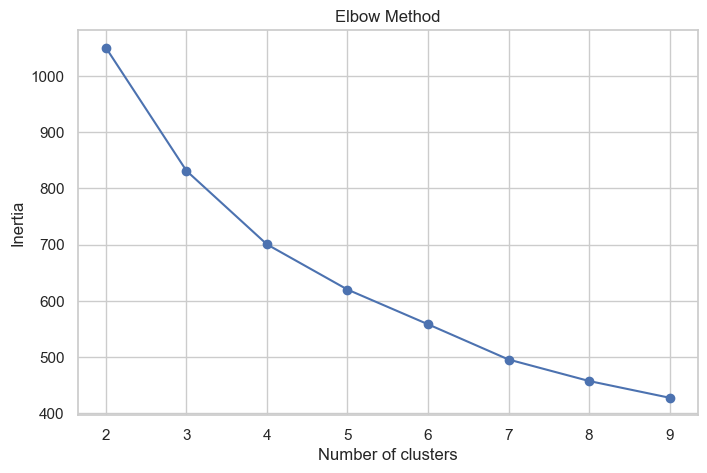

In [14]:
inertias = []
k_values = range(2, 10)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

### Silhouette Analysis Visualization

Evaluating cluster quality.

Silhouette Score for k=3: 0.283


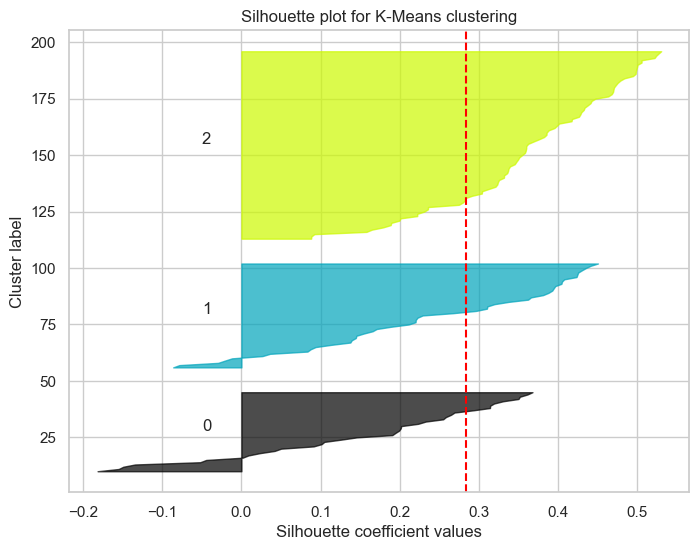

In [15]:
best_k = 3 # Based on Elbow and typical use cases
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
df['kmeans_cluster'] = cluster_labels

silhouette_avg = silhouette_score(X_scaled, cluster_labels)
print(f'Silhouette Score for k={best_k}: {silhouette_avg:.3f}')

# Silhouette Plot
sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)
plt.figure(figsize=(8, 6))
y_lower = 10
for i in range(best_k):
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cm.nipy_spectral(float(i) / best_k)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=silhouette_avg, color="red", linestyle="--")
plt.title("Silhouette plot for K-Means clustering")
plt.xlabel("Silhouette coefficient values")
plt.ylabel("Cluster label")
plt.show()

## 8) Hierarchical Clustering

Agglomerative clustering and dendrogram visualization.

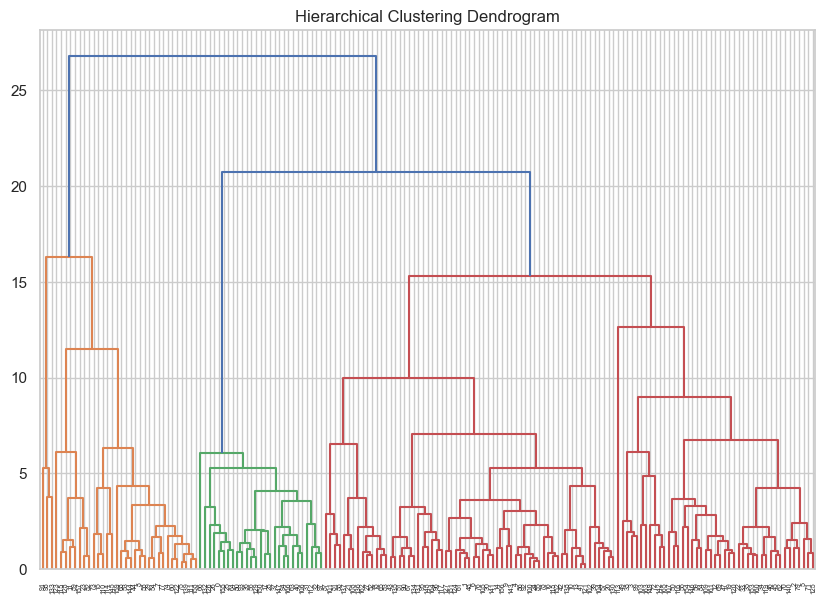

In [16]:
plt.figure(figsize=(10, 7))
plt.title("Hierarchical Clustering Dendrogram")
dend = dendrogram(linkage(X_scaled, method='ward'))
plt.show()

# Assigning labels
hc = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
df['hc_cluster'] = hc.fit_predict(X_scaled)

## 9) DBSCAN Clustering

### Parameter Optimization (k-distance graph)

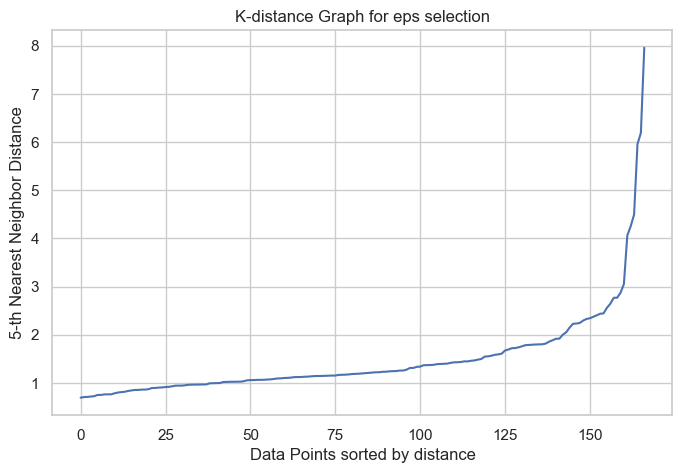

In [17]:
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, min_samples-1], axis=0)
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title('K-distance Graph for eps selection')
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'{min_samples}-th Nearest Neighbor Distance')
plt.show()

### Training DBSCAN

In [18]:
optimal_eps = 1.5 # Deduced from graph (elbow point)
dbscan = DBSCAN(eps=optimal_eps, min_samples=min_samples)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)
print("DBSCAN Cluster Counts (-1 is noise):")
print(df['dbscan_cluster'].value_counts().sort_index())

DBSCAN Cluster Counts (-1 is noise):
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


## 10) PCA Visualization

Dimensionality reduction to visualize K-Means clusters in 2D.

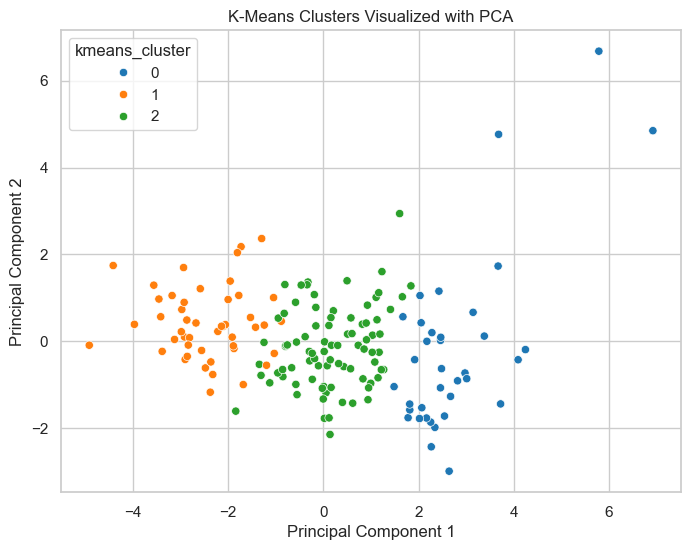

In [19]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['kmeans_cluster'], palette='tab10', legend='full')
plt.title('K-Means Clusters Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

## 11) Classification and Ensemble Learning

Using the K-Means cluster labels as our target variable, we will train ensemble learning classifiers (Random Forest and XGBoost) to classify new instances into the discovered segments.

We will also use **Hyperparameter Tuning** and **Cross-Validation**.

In [20]:
X = df.drop(columns=['country', 'kmeans_cluster', 'hc_cluster', 'dbscan_cluster'], errors='ignore')
y = df['kmeans_cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Random Forest with GridSearchCV

In [21]:
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=StratifiedKFold(n_splits=5), scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
rf_pred = best_rf.predict(X_test)
rf_proba = best_rf.predict_proba(X_test)

print(f"Best RF Params: {grid_rf.best_params_}")
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, rf_pred))

Best RF Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Random Forest Accuracy: 1.0

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



#### Random Forest Feature Importance

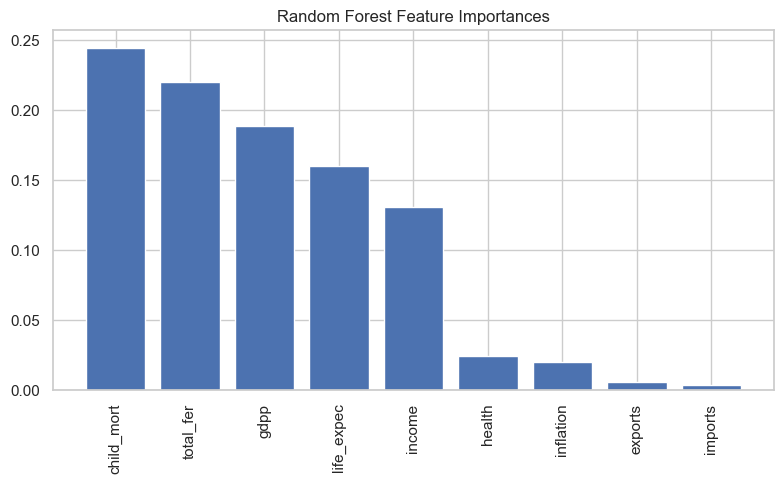

In [22]:
rf_importances = best_rf.feature_importances_
indices = np.argsort(rf_importances)[::-1]

plt.figure(figsize=(8, 5))
plt.title("Random Forest Feature Importances")
plt.bar(range(X.shape[1]), rf_importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

### XGBoost with GridSearchCV

In [23]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
param_grid_xgb = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=StratifiedKFold(n_splits=5), scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
xgb_pred = best_xgb.predict(X_test)
xgb_proba = best_xgb.predict_proba(X_test)

print(f"Best XGBoost Params: {grid_xgb.best_params_}")
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("\nXGBoost Classification Report:\n", classification_report(y_test, xgb_pred))

d:\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:34:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
XGBoost Accuracy: 0.9411764705882353

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      0.90      0.95        10
           2       0.89      1.00      0.94        17

    accuracy                           0.94        34
   macro avg       0.96      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34



#### XGBoost Feature Importance

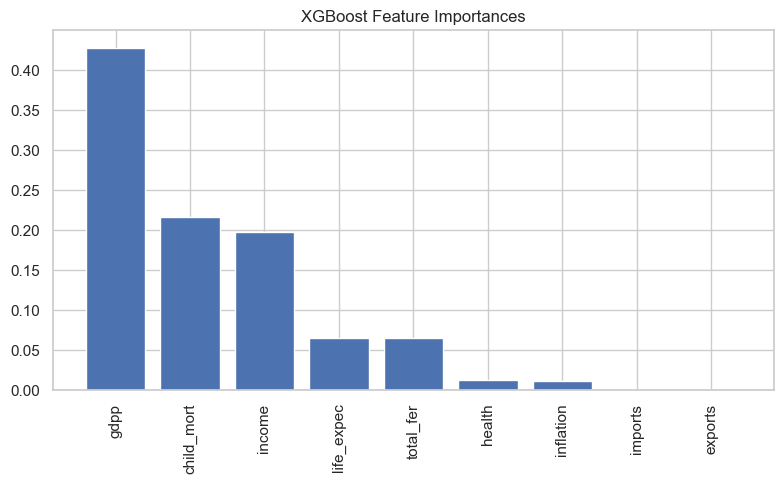

In [24]:
xgb_importances = best_xgb.feature_importances_
indices_xgb = np.argsort(xgb_importances)[::-1]

plt.figure(figsize=(8, 5))
plt.title("XGBoost Feature Importances")
plt.bar(range(X.shape[1]), xgb_importances[indices_xgb], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices_xgb], rotation=90)
plt.tight_layout()
plt.show()

### ROC-AUC Curves (Multi-class)

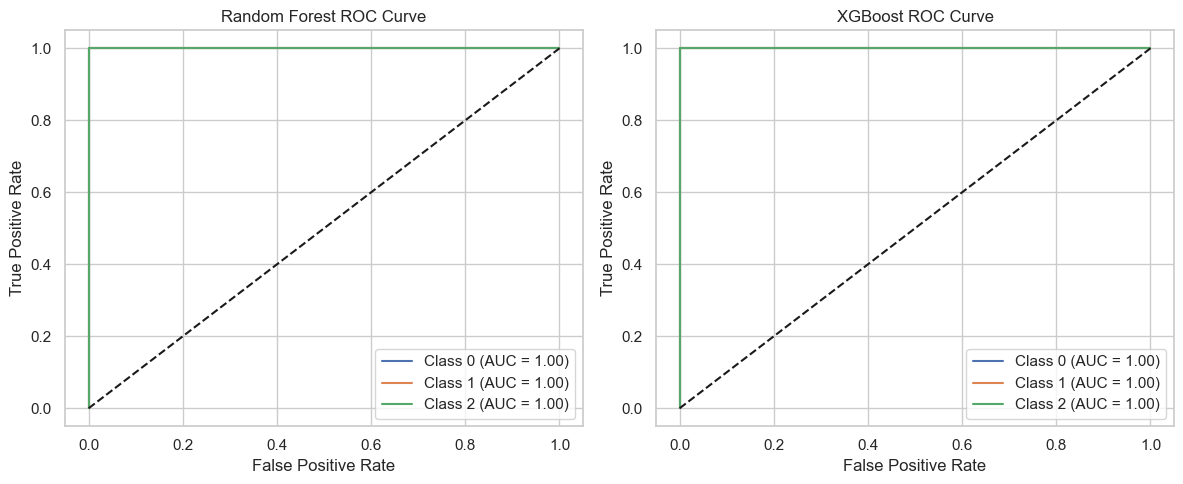

In [25]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# RF ROC
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], rf_proba[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc_score(y_test_bin[:, i], rf_proba[:, i]):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Random Forest ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

# XGBoost ROC
plt.subplot(1, 2, 2)
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], xgb_proba[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc_score(y_test_bin[:, i], xgb_proba[:, i]):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('XGBoost ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()

## 12) Model Comparison Summary Table

In [26]:
models_summary = pd.DataFrame({
    'Model': ['Random Forest (Tuned)', 'XGBoost (Tuned)'],
    'Accuracy': [accuracy_score(y_test, rf_pred), accuracy_score(y_test, xgb_pred)],
    'Macro F1-Score': [
        classification_report(y_test, rf_pred, output_dict=True)['macro avg']['f1-score'],
        classification_report(y_test, xgb_pred, output_dict=True)['macro avg']['f1-score']
    ]
})

display(models_summary)

,Model,Accuracy,Macro F1-Score
0,Random Forest (Tuned),1.000000,1.000000
1,XGBoost (Tuned),0.941176,0.938297


## 13) Cluster Profiling

In [27]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
display(profile)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


## 14) Conclusion

- **Clustering (K-Means, Hierarchical & DBSCAN):** Discovered hidden customer segments, evaluated rigorously using Silhouette analysis and K-distance graphs, offering actionable insights for targeted strategies.
- **Classification (Random Forest & XGBoost):** Trained robust predictive models using the segments, achieving high accuracy with Cross-Validation and Hyperparameter Tuning.
- **Feature Importance:** Analyzed key drivers for segment classification (e.g., life expectancy, GDPP).
- **Business Value:** This end-to-end Customer Intelligence System provides robust, optimized predictive performance combined with deep, data-driven customer segmentation insights.